**Analysis File**

Simulation columns: ['t', 'price', 'fundamental', 'momentum', 'excess_demand']


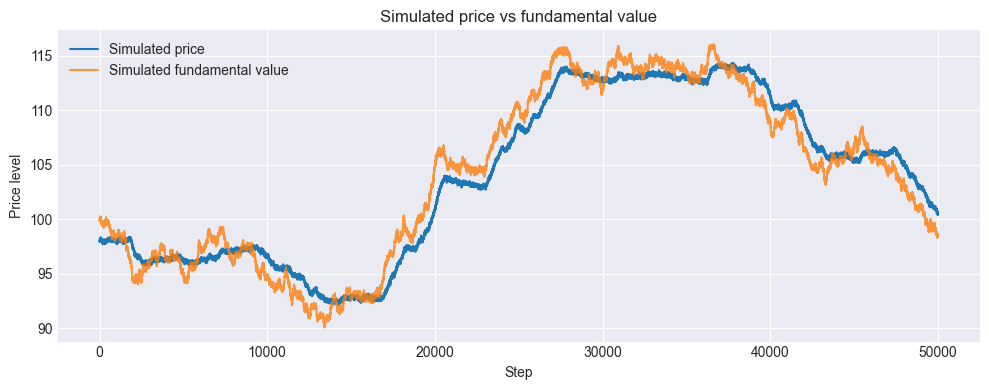

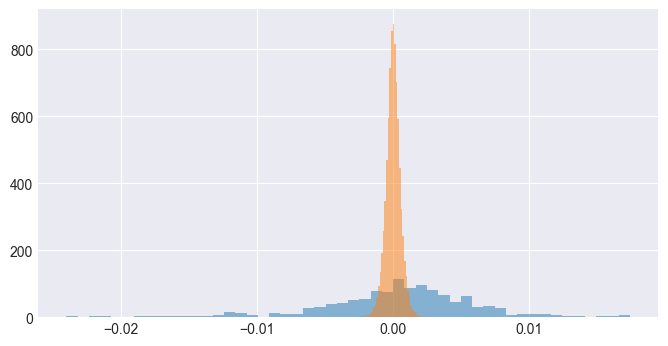

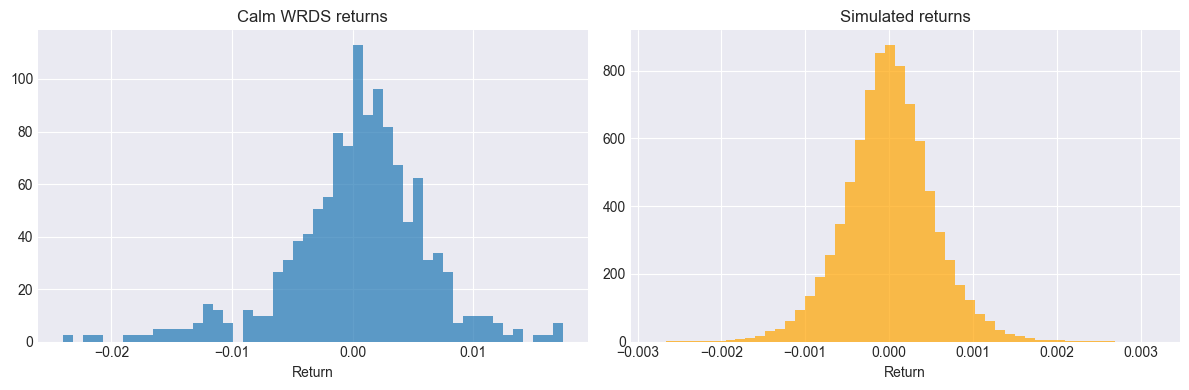

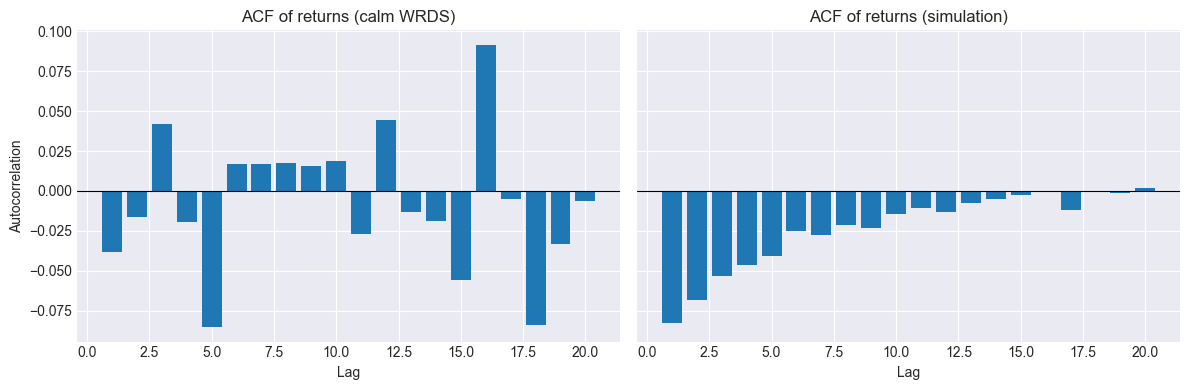

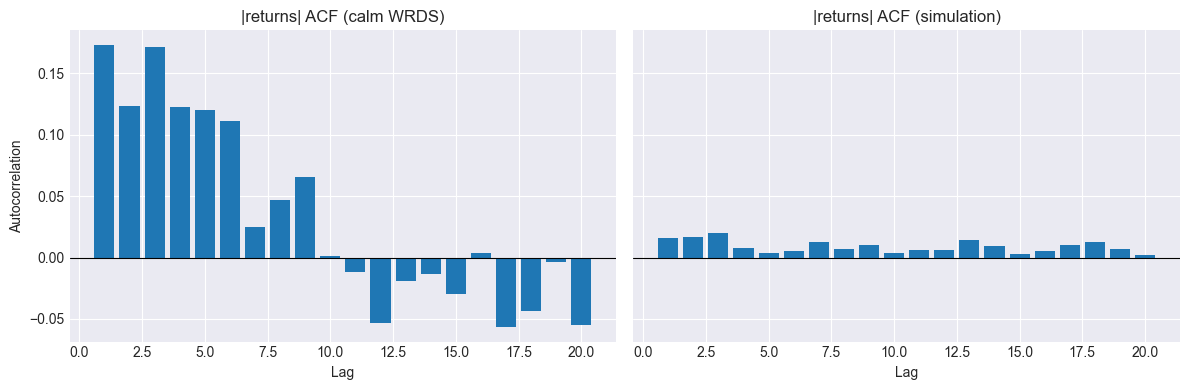

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

# -----------------------------
# 1. Load WRDS calm & stressed data
# -----------------------------
calm_path = "data/thesis_data_calm.csv"
stress_path = "data/thesis_data_stressed.csv"

df_calm = pd.read_csv(calm_path)
df_stress = pd.read_csv(stress_path)

for df in (df_calm, df_stress):
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

# Use WRDS daily close as empirical price
df_calm["price_calm"] = df_calm["DPrice"]
df_stress["price_stress"] = df_stress["DPrice"]

# Use WRDS-provided daily return as primary empirical return
# (Ret_mkt_t is from WRDS IID)
df_calm["ret_calm"] = df_calm["Ret_mkt_t"]
df_stress["ret_stress"] = df_stress["Ret_mkt_t"]

# -----------------------------
# 2. Load simulation history
# -----------------------------
sim_path = Path("output/trading_core_history.csv")
if not sim_path.exists():
    raise FileNotFoundError(
        f"{sim_path} not found. Run the Simudyne model so it writes the trading_core_history.csv first."
    )

df_sim = pd.read_csv(sim_path)

# Try to be robust to column naming
# Expect something like: step, price, fundamentalValue
print("Simulation columns:", df_sim.columns.tolist())

# Infer index
if "step" in df_sim.columns:
    df_sim.set_index("step", inplace=True)

# rename if needed (edit here if your CSV uses different names)
price_col = "price"
fund_col = "fundamental"

if price_col not in df_sim.columns:
    raise KeyError(f"'{price_col}' column not found in simulation CSV; columns = {df_sim.columns}")
if fund_col not in df_sim.columns:
    raise KeyError(f"'{fund_col}' column not found in simulation CSV; columns = {df_sim.columns}")

df_sim["ret_sim"] = df_sim[price_col].pct_change()

# -----------------------------
# 3. Plot simulated price vs fundamental value
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sim.index, df_sim[price_col], label="Simulated price")
ax.plot(df_sim.index, df_sim[fund_col], label="Simulated fundamental value", alpha=0.8)
ax.set_xlabel("Step")
ax.set_ylabel("Price level")
ax.set_title("Simulated price vs fundamental value")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Return distributions: calm vs simulated
# -----------------------------
# Align sample lengths roughly (optional)
ret_calm = df_calm["ret_calm"].dropna()
ret_sim = df_sim["ret_sim"].dropna()

# If simulation has many more points, you can subsample to daily if you want.
# For now, just compare raw distributions.
fig, ax = plt.subplots(figsize=(8, 4))
bins = 50

ax.hist(
    ret_calm,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Calm WRDS (daily Ret_mkt_t)",
)
ax.hist(
    ret_sim,
    bins=bins,
    density=True,
    alpha=0.5,
    label="Simulation (per step returns)",
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

axes[0].hist(ret_calm, bins=50, density=True, alpha=0.7)
axes[0].set_title("Calm WRDS returns")
axes[0].set_xlabel("Return")

axes[1].hist(ret_sim, bins=50, density=True, alpha=0.7, color="orange")
axes[1].set_title("Simulated returns")
axes[1].set_xlabel("Return")

plt.tight_layout()
plt.show()

# -----------------------------
# 5. Autocorrelation of returns: calm vs simulated
# -----------------------------
def acf(series, max_lag):
    """Simple ACF using pandas autocorr."""
    series = series.dropna()
    return [series.autocorr(lag=lag) for lag in range(1, max_lag + 1)]

max_lag = 20
acf_calm = acf(ret_calm, max_lag)
acf_sim = acf(ret_sim, max_lag)

lags = np.arange(1, max_lag + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(lags, acf_calm)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("ACF of returns (calm WRDS)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

axes[1].bar(lags, acf_sim)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("ACF of returns (simulation)")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()

# (Optional) ACF of absolute returns to look at volatility clustering
acf_abs_calm = acf(ret_calm.abs(), max_lag)
acf_abs_sim = acf(ret_sim.abs(), max_lag)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(lags, acf_abs_calm)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("|returns| ACF (calm WRDS)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

axes[1].bar(lags, acf_abs_sim)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("|returns| ACF (simulation)")
axes[1].set_xlabel("Lag")

plt.tight_layout()
plt.show()